# Proyecto EDA · Campañas de marketing de un banco portugués

Análisis exploratorio de las campañas telefónicas de un banco para vender un **depósito a plazo**. Se combinan dos fuentes:

- `bank-additional.csv`: 43.000 contactos (perfil, campaña, contexto macroeconómico y resultado `y`).
- `customer-details.xlsx`: datos demográficos de los clientes, repartidos en **3 hojas** (2012, 2013 y 2014).

**Contenido del notebook**
1. Carga y diagnóstico de los datos en bruto
2. Unión de las dos fuentes
3. Limpieza y transformación
4. Análisis descriptivo
5. Visualización
6. Conclusiones

## 0. Configuración

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.3f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 12})

# Rutas del proyecto
RUTA_BRUTOS = Path("Datos_brutos")
RUTA_TRANSFORMADOS = Path("transformados")
RUTA_GRAFICOS = Path("graficos")
RUTA_TRANSFORMADOS.mkdir(exist_ok=True)
RUTA_GRAFICOS.mkdir(exist_ok=True)

COLOR_SI, COLOR_NO = "#2a9d8f", "#c9ced6"

ModuleNotFoundError: No module named 'seaborn'

## 1. Carga y diagnóstico de los datos en bruto

Ojo con el Excel: tiene **3 hojas**. `pd.read_excel` sin más solo lee la primera (2012), y eso deja fuera a más de la mitad de los clientes. Con `sheet_name=None` se leen todas en un diccionario y se concatenan.

In [ ]:
# Los ficheros traen una primera columna sin nombre ("Unnamed: 0"): es un índice antiguo y no se lee
sin_indice = lambda columna: not columna.startswith("Unnamed")

bancos = pd.read_csv(RUTA_BRUTOS / "bank-additional.csv", usecols=sin_indice)

hojas = pd.read_excel(RUTA_BRUTOS / "customer-details.xlsx", sheet_name=None, usecols=sin_indice)
clientes = pd.concat(hojas.values(), ignore_index=True)

print("Filas por hoja del Excel:", {nombre: len(hoja) for nombre, hoja in hojas.items()})
print(f"CSV: {bancos.shape} | Excel (3 hojas juntas): {clientes.shape}")

Filas por hoja del Excel: {'2012': 20115, '2013': 8965, '2014': 14090}
CSV: (43000, 23) | Excel (3 hojas juntas): (43170, 6)


In [ ]:
bancos.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,NaN,housemaid,MARRIED,basic.4y,0.000,0.000,0.000,telephone,261,1,999,0,NONEXISTENT,1.100,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.000,services,MARRIED,high.school,NaN,0.000,0.000,telephone,149,1,999,0,NONEXISTENT,1.100,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,37.000,services,MARRIED,high.school,0.000,1.000,0.000,telephone,226,1,999,0,NONEXISTENT,1.100,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.000,admin.,MARRIED,basic.6y,0.000,0.000,0.000,telephone,151,1,999,0,NONEXISTENT,1.100,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.000,services,MARRIED,high.school,0.000,0.000,1.000,telephone,307,1,999,0,NONEXISTENT,1.100,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [ ]:
bancos.info()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             37880 non-null  float64
 1   job             42655 non-null  str    
 2   marital         42915 non-null  str    
 3   education       41193 non-null  str    
 4   default         34019 non-null  float64
 5   housing         41974 non-null  float64
 6   loan            41974 non-null  float64
 7   contact         43000 non-null  str    
 8   duration        43000 non-null  int64  
 9   campaign        43000 non-null  int64  
 10  pdays           43000 non-null  int64  
 11  previous        43000 non-null  int64  
 12  poutcome        43000 non-null  str    
 13  emp.var.rate    43000 non-null  float64
 14  cons.price.idx  42529 non-null  str    
 15  cons.conf.idx   43000 non-null  str    
 16  euribor3m       33744 non-null  str    
 17  nr.employed     43000 non-null  str    
 1

In [ ]:
# Nulos por columna (número y porcentaje) en el CSV
nulos = bancos.isna().sum()
pd.DataFrame({"nulos": nulos, "%": nulos / len(bancos) * 100}).query("nulos > 0").sort_values("nulos", ascending=False)

,nulos,%
euribor3m,9256,21.526
default,8981,20.886
age,5120,11.907
education,1807,4.202
loan,1026,2.386
housing,1026,2.386
cons.price.idx,471,1.095
job,345,0.802
date,248,0.577
marital,85,0.198


In [ ]:
# Comprobaciones de integridad antes de unir
print("Duplicados en id_ (CSV):     ", bancos["id_"].duplicated().sum())
print("Duplicados en ID (Excel):    ", clientes["ID"].duplicated().sum())
print("Filas totalmente duplicadas: ", bancos.duplicated().sum())
print(f"% de id_ del CSV presentes en el Excel: {bancos['id_'].isin(clientes['ID']).mean():.1%}")

Duplicados en id_ (CSV):      0
Duplicados en ID (Excel):     0
Filas totalmente duplicadas:  0
% de id_ del CSV presentes en el Excel: 100.0%


## 2. Unión de las dos fuentes

Se hace un `left merge` desde el CSV (es la tabla principal: un contacto por fila). Como `id_` y `ID` son únicos, la unión tiene que ser 1 a 1 y **no se debe perder ni duplicar ninguna fila**. `validate="one_to_one"` lo comprueba por nosotros.

In [ ]:
df = bancos.merge(clientes, left_on="id_", right_on="ID", how="left", validate="one_to_one")

assert len(df) == len(bancos), "El merge ha cambiado el número de filas"
print(f"Filas tras el merge: {len(df):,} | Clientes sin datos del Excel: {df['ID'].isna().sum()}")

# ID e id_ son la misma clave: nos quedamos con una
df = df.drop(columns="ID")

Filas tras el merge: 43,000 | Clientes sin datos del Excel: 0


## 3. Limpieza y transformación

Problemas detectados en el diagnóstico y cómo se tratan:

| Problema | Tratamiento |
|---|---|
| `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` son texto con coma decimal (`"93,994"`) | Convertir a número |
| `date` es texto en español (`"2-agosto-2019"`) | Convertir a `datetime` y derivar `contact_month` y `contact_year` |
| Texto en mayúsculas/minúsculas mezcladas (`MARRIED`, `NONEXISTENT`) | Normalizar a minúsculas |
| `y` es `yes/no` | Codificar como 1/0 |
| `pdays = 999` es un código, no 999 días | Sustituir por nulo y crear `contactado_antes` a partir de `previous` |
| `default`: prácticamente todo 0 | Eliminar (no aporta información) |
| `latitude`/`longitude` | Eliminar: son coordenadas de EE. UU., incoherentes con un banco portugués |
| Nulos en variables categóricas | Categoría `unknown` |
| Nulos en `age` | Mediana de la edad de su profesión |
| Nulos en variables macroeconómicas | Imputación por grupo (ver más abajo) |

### 3.1 Funciones auxiliares

In [ ]:
MESES = {
    "enero": "01", "febrero": "02", "marzo": "03", "abril": "04", "mayo": "05", "junio": "06",
    "julio": "07", "agosto": "08", "septiembre": "09", "octubre": "10", "noviembre": "11", "diciembre": "12",
}


def coma_a_numero(serie: pd.Series) -> pd.Series:
    """Convierte texto con coma decimal ('93,994') a float. Lo no convertible pasa a NaN."""
    return pd.to_numeric(serie.astype("string").str.replace(",", ".", regex=False), errors="coerce").astype("float64")


def fecha_es_a_datetime(serie: pd.Series) -> pd.Series:
    """Convierte fechas tipo '2-agosto-2019' a datetime. Las fechas nulas pasan a NaT."""
    partes = serie.str.lower().str.split("-", expand=True)
    partes[1] = partes[1].map(MESES)
    return pd.to_datetime(partes[0] + "-" + partes[1] + "-" + partes[2], format="%d-%m-%Y", errors="coerce")


def rellenar_por_grupo(df: pd.DataFrame, columna: str, grupo: list[str], estadistico: str) -> pd.Series:
    """Rellena los nulos de `columna` con un estadístico (median, first...) calculado dentro de cada grupo."""
    return df[columna].fillna(df.groupby(grupo)[columna].transform(estadistico))


def tasa_conversion(df: pd.DataFrame, columna: str) -> pd.DataFrame:
    """Nº de clientes y % que suscribe el depósito para cada valor de `columna`."""
    return (
        df.groupby(columna, observed=True)["y"]
        .agg(clientes="size", conversion="mean")
        .assign(conversion=lambda t: t["conversion"] * 100)
    )

### 3.2 Tipos de datos y texto

In [ ]:
COLS_MACRO_TEXTO = ["cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
COLS_CATEGORICAS = ["job", "marital", "education", "contact", "poutcome"]

# Números con coma decimal -> float
df[COLS_MACRO_TEXTO] = df[COLS_MACRO_TEXTO].apply(coma_a_numero)

# Texto: minúsculas y sin espacios sobrantes
df[COLS_CATEGORICAS] = df[COLS_CATEGORICAS].apply(lambda s: s.str.lower().str.strip())

# Fecha de contacto y derivadas
df["date"] = fecha_es_a_datetime(df["date"])
df["contact_month"] = df["date"].dt.month.astype("Int64")
df["contact_year"] = df["date"].dt.year.astype("Int64")

# Variable objetivo: 1 = suscribe el depósito, 0 = no
df["y"] = df["y"].str.lower().map({"yes": 1, "no": 0}).astype("int8")

# Indicadores 0/1 con nulos -> enteros que admiten nulos
df[["housing", "loan"]] = df[["housing", "loan"]].astype("Int64")

df[COLS_MACRO_TEXTO + ["date", "contact_month", "contact_year", "y"]].dtypes

cons.price.idx           float64
cons.conf.idx            float64
euribor3m                float64
nr.employed              float64
date              datetime64[us]
contact_month              Int64
contact_year               Int64
y                           int8
dtype: object

### 3.3 Columnas que no aportan

`default` es 0 en prácticamente todos los clientes con dato, y además tiene un 21% de nulos, así que no permite distinguir a nadie.

In [ ]:
print(df["default"].value_counts(dropna=False))
df = df.drop(columns=["default", "latitude", "longitude"])

default
0.000    34016
NaN       8981
1.000        3
Name: count, dtype: int64


### 3.4 `pdays` y contactos anteriores

`pdays = 999` es un código de "sin dato", no 999 días. Tratarlo como número falsearía medias y correlaciones, así que se pasa a nulo.

Ojo: **no equivale a "nunca contactado"**. Hay clientes con contactos previos (`previous > 0`) y `pdays = 999`, y todos son campañas anteriores fallidas. Por eso el indicador `contactado_antes` se construye con `previous`, que es fiable, y no con `pdays`.

In [ ]:
print("pdays = 999:", (df["pdays"] == 999).sum(), "filas")
print("De ellas, con contactos previos (previous > 0):", ((df["pdays"] == 999) & (df["previous"] > 0)).sum())

# Cruce que explica la situación: los 999 con contacto previo son todos campañas anteriores fallidas
print(pd.crosstab(df["poutcome"], df["pdays"] == 999, rownames=["poutcome"], colnames=["pdays == 999"]))

df["contactado_antes"] = (df["previous"] > 0).astype("int8")
df["pdays"] = df["pdays"].replace(999, np.nan)
df[["previous", "pdays", "contactado_antes"]].describe().T

pdays = 999: 41412 filas
De ellas, con contactos previos (previous > 0): 4309
pdays == 999  False  True 
poutcome                  
failure         152   4309
nonexistent       0  37103
success        1436      0


,count,mean,std,min,25%,50%,75%,max
previous,"43,000.000",0.174,0.497,0.000,0.000,0.000,0.000,7.000
pdays,"1,588.000",6.072,3.863,0.000,3.000,6.000,7.000,27.000
contactado_antes,"43,000.000",0.137,0.344,0.000,0.000,0.000,0.000,1.000


### 3.5 Valores nulos

Antes de imputar, se comprueba que los nulos de `age` no dependen del resultado (si faltaran más en los que suscriben, imputar sesgaría el análisis).

In [ ]:
print("% nulos en age según y:")
print((df["age"].isna().groupby(df["y"]).mean() * 100).round(2).to_string())

% nulos en age según y:
y
0   11.900
1   11.930


In [ ]:
# Categóricas: los nulos pasan a una categoría propia
df[COLS_CATEGORICAS] = df[COLS_CATEGORICAS].fillna("unknown")

# Edad: mediana de su profesión (los nulos de job ya son 'unknown')
df["age"] = rellenar_por_grupo(df, "age", ["job"], "median").round().astype("int16")

**Variables macroeconómicas.** `emp.var.rate`, `cons.conf.idx` y `nr.employed` no tienen nulos y, juntas, identifican un "periodo económico". Dentro de cada periodo, el índice de precios (`cons.price.idx`) tiene **un único valor posible**, así que sus nulos se pueden recuperar con exactitud. El `euribor3m` sí varía un poco dentro de cada periodo, y ahí se usa la mediana del grupo.

In [ ]:
GRUPO_MACRO = ["emp.var.rate", "cons.conf.idx", "nr.employed"]

# Comprobación: valores distintos de cons.price.idx por periodo (debe ser 1 en todos)
print("Máx. valores distintos de cons.price.idx por periodo:", df.groupby(GRUPO_MACRO)["cons.price.idx"].nunique().max())

df["cons.price.idx"] = rellenar_por_grupo(df, "cons.price.idx", GRUPO_MACRO, "first")
df["euribor3m"] = rellenar_por_grupo(df, "euribor3m", GRUPO_MACRO, "median")

Máx. valores distintos de cons.price.idx por periodo: 1


In [ ]:
# Nulos que quedan
restantes = df.isna().sum()
restantes[restantes > 0]

housing           1026
loan              1026
pdays            41412
date               248
contact_month      248
contact_year       248
dtype: int64

Quedan sin imputar, a propósito:

- `date` (248 filas, 0,6%): una fecha inventada distorsionaría el análisis temporal. Esas filas se conservan y solo se excluyen en los gráficos por fecha.
- `housing` y `loan` (2,4%): son datos personales del cliente y no hay forma razonable de deducirlos. Las funciones de pandas ignoran los nulos.
- `pdays`: el nulo es el código 999 (sin dato de días desde el último contacto). La información de si hubo contacto previo ya está en `previous` y `contactado_antes`.

### 3.6 Outliers

`duration` y `campaign` tienen colas muy largas. Se cuantifican con el criterio del rango intercuartílico (IQR), pero **no se eliminan**: son contactos reales, y una llamada muy larga es justo lo que se espera de un cliente interesado.

In [ ]:
def resumen_outliers(df: pd.DataFrame, columnas: list[str]) -> pd.DataFrame:
    """Cuenta los valores fuera de [Q1 - 1.5·IQR, Q3 + 1.5·IQR] en cada columna."""
    filas = {}
    for col in columnas:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        fuera = ~df[col].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
        filas[col] = {"limite_sup": q3 + 1.5 * iqr, "maximo": df[col].max(), "n_outliers": fuera.sum(), "%": fuera.mean() * 100}
    return pd.DataFrame(filas).T


resumen_outliers(df, ["age", "duration", "campaign", "Income", "NumWebVisitsMonth"])

,limite_sup,maximo,n_outliers,%
age,65.500,98.000,576.000,1.340
duration,644.500,"4,918.000","3,072.000",7.144
campaign,6.000,56.000,"2,504.000",5.823
Income,"267,446.250","180,802.000",0.000,0.000
NumWebVisitsMonth,49.000,32.000,0.000,0.000


In [ ]:
print("Llamadas con duración 0:", (df["duration"] == 0).sum(), "| suscripciones en ellas:", df.loc[df["duration"] == 0, "y"].sum())

Llamadas con duración 0: 4 | suscripciones en ellas: 0


### 3.7 Variables nuevas

In [ ]:
df["grupo_edad"] = pd.cut(
    df["age"], bins=[0, 25, 35, 45, 55, 65, 120],
    labels=["<=25", "26-35", "36-45", "46-55", "56-65", "66+"],
)
df["tramo_ingresos"] = pd.qcut(df["Income"], 4, labels=["Q1 (bajos)", "Q2", "Q3", "Q4 (altos)"])
df["total_hijos"] = df["Kidhome"] + df["Teenhome"]
df["tramo_contactos"] = pd.cut(
    df["campaign"], bins=[0, 1, 2, 3, 5, 100], labels=["1", "2", "3", "4-5", "6+"],
)
df["tramo_visitas_web"] = pd.cut(
    df["NumWebVisitsMonth"], bins=[0, 8, 16, 24, 32], labels=["1-8", "9-16", "17-24", "25-32"],
)
df["anio_alta"] = df["Dt_Customer"].dt.year
# Años entre que se hizo cliente y se le llamó
df["antiguedad_anios"] = (df["date"] - df["Dt_Customer"]).dt.days / 365.25

df.head()

,age,job,marital,education,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,id_,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,contact_month,contact_year,contactado_antes,grupo_edad,tramo_ingresos,total_hijos,tramo_contactos,tramo_visitas_web,anio_alta,antiguedad_anios
0,45,housemaid,married,basic.4y,0,0,telephone,261,1,NaN,0,nonexistent,1.100,93.994,-36.400,4.857,"5,191.000",0,2019-08-02,089b39d8-e4d0-461b-87d4-814d71e0e079,161770,1,0,2012-04-04,29,8,2019,0,36-45,Q4 (altos),1,1,25-32,2012,7.326
1,57,services,married,high.school,0,0,telephone,149,1,NaN,0,nonexistent,1.100,93.994,-36.400,4.857,"5,191.000",0,2016-09-14,e9d37224-cb6f-4942-98d7-46672963d097,85477,1,1,2012-12-30,7,9,2016,0,56-65,Q2,2,1,1-8,2012,3.707
2,37,services,married,high.school,1,0,telephone,226,1,NaN,0,nonexistent,1.100,93.994,-36.400,4.857,"5,191.000",0,2019-02-15,3f9f49b5-e410-4948-bf6e-f9244f04918b,147233,1,1,2012-02-02,5,2,2019,0,36-45,Q4 (altos),2,1,1-8,2012,7.036
3,40,admin.,married,basic.6y,0,0,telephone,151,1,NaN,0,nonexistent,1.100,93.994,-36.400,4.857,"5,191.000",0,2015-11-29,9991fafb-4447-451a-8be2-b0df6098d13e,121393,1,2,2012-12-21,29,11,2015,0,36-45,Q3,3,1,25-32,2012,2.938
4,56,services,married,high.school,0,1,telephone,307,1,NaN,0,nonexistent,1.100,93.994,-36.400,4.857,"5,191.000",0,2017-01-29,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,63164,1,2,2012-06-20,20,1,2017,0,56-65,Q2,3,1,17-24,2012,4.611


### 3.8 Validación final y guardado

In [ ]:
# Controles de calidad: si algo falla, el notebook se detiene aquí
assert len(df) == 43000
assert df["id_"].is_unique
assert df["y"].isin([0, 1]).all()
assert df[["age", "job", "marital", "education", "euribor3m", "cons.price.idx"]].notna().all().all()
assert (df["Dt_Customer"].dt.year.between(2012, 2014)).all()

df.to_csv(RUTA_TRANSFORMADOS / "bank_clean.csv", index=False)
print(f"Guardado: {RUTA_TRANSFORMADOS / 'bank_clean.csv'} -> {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.info()

Guardado: transformados/bank_clean.csv -> 43,000 filas x 35 columnas
<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   age                43000 non-null  int16         
 1   job                43000 non-null  str           
 2   marital            43000 non-null  str           
 3   education          43000 non-null  str           
 4   housing            41974 non-null  Int64         
 5   loan               41974 non-null  Int64         
 6   contact            43000 non-null  str           
 7   duration           43000 non-null  int64         
 8   campaign           43000 non-null  int64         
 9   pdays              1588 non-null   float64       
 10  previous           43000 non-null  int64         
 11  poutcome           43000 non-null  str           
 12  emp.var.rate       43000 non-null  float64       
 13  con

## 4. Análisis descriptivo

### 4.1 Variable objetivo

In [ ]:
conteo = df["y"].value_counts().rename({0: "No suscribe", 1: "Suscribe"})
pd.DataFrame({"clientes": conteo, "%": conteo / len(df) * 100})

,clientes,%
y,,
No suscribe,38156,88.735
Suscribe,4844,11.265


Solo alrededor de **1 de cada 9** clientes contratados suscribe el depósito: la variable objetivo está **desbalanceada**. Hay que tenerlo en cuenta al interpretar: una "tasa de conversión" del 11% es la referencia con la que comparar cada segmento.

### 4.2 Variables numéricas: media, mediana, dispersión y asimetría

In [ ]:
NUMERICAS = ["age", "duration", "campaign", "previous", "Income", "NumWebVisitsMonth", "total_hijos",
             "antiguedad_anios", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

resumen = df[NUMERICAS].agg(["mean", "median", "std", "min", "max", "skew"]).T
resumen

,mean,median,std,min,max,skew
age,39.815,38.000,9.962,17.000,98.000,0.880
duration,257.739,179.000,258.666,0.000,"4,918.000",3.320
campaign,2.567,2.000,2.772,1.000,56.000,4.771
previous,0.174,0.000,0.497,0.000,7.000,3.832
Income,"93,241.200","93,050.500","50,498.316","5,841.000","180,802.000",0.003
NumWebVisitsMonth,16.590,17.000,9.239,1.000,32.000,-0.008
total_hijos,2.003,2.000,1.153,0.000,4.000,-0.007
antiguedad_anios,4.139,4.148,1.724,0.022,7.997,-0.035
emp.var.rate,0.077,1.100,1.574,-3.400,1.400,-0.718
cons.price.idx,93.574,93.749,0.580,92.201,94.767,-0.227


Lectura rápida: en `duration` y `campaign` la **media es mucho mayor que la mediana** y la asimetría es alta (cola a la derecha: unas pocas llamadas larguísimas y clientes contactados muchas veces). `Income`, `NumWebVisitsMonth`, `Kidhome` y `Teenhome` tienen distribuciones casi uniformes (media ≈ mediana, asimetría ≈ 0).

### 4.3 Variables categóricas

In [ ]:
for col in ["job", "marital", "education", "contact", "poutcome"]:
    print(f"\n--- {col} ---")
    print((df[col].value_counts(normalize=True) * 100).round(1).to_string())


--- job ---
job
admin.          25.300
blue-collar     22.500
technician      16.300
services         9.700
management       7.100
retired          4.200
entrepreneur     3.500
self-employed    3.500
housemaid        2.600
unemployed       2.500
student          2.100
unknown          0.800

--- marital ---
marital
married    60.500
single     28.200
divorced   11.200
unknown     0.200

--- education ---
education
university.degree     29.600
high.school           23.100
basic.9y              14.700
professional.course   12.700
basic.4y              10.100
basic.6y               5.500
unknown                4.200
illiterate             0.000

--- contact ---
contact
cellular    63.700
telephone   36.300

--- poutcome ---
poutcome
nonexistent   86.300
failure       10.400
success        3.300


### 4.4 Tasa de suscripción por segmento

In [ ]:
tasa_conversion(df, "job").sort_values("conversion", ascending=False)

,clientes,conversion
job,,
student,903,31.340
retired,1790,25.196
unemployed,1063,14.393
admin.,10873,13.014
unknown,345,11.304
management,3050,11.213
technician,7026,10.845
self-employed,1489,10.813
housemaid,1123,9.884


In [ ]:
tasa_conversion(df, "poutcome").sort_values("conversion", ascending=False)

,clientes,conversion
poutcome,,
success,1436,65.320
failure,4461,14.234
nonexistent,37103,8.816


In [ ]:
# Perfil medio por profesión (agrupación con varias agregaciones)
(df.groupby("job")
   .agg(clientes=("y", "size"), conversion=("y", "mean"), edad_media=("age", "mean"),
        ingresos_medios=("Income", "mean"), duracion_media=("duration", "mean"))
   .assign(conversion=lambda t: t["conversion"] * 100)
   .sort_values("conversion", ascending=False))

,clientes,conversion,edad_media,ingresos_medios,duracion_media
job,,,,,
student,903,31.340,25.689,"93,547.689",282.567
retired,1790,25.196,61.760,"92,683.894",272.534
unemployed,1063,14.393,39.405,"93,490.263",249.818
admin.,10873,13.014,37.775,"93,285.093",253.736
unknown,345,11.304,45.545,"94,065.299",241.936
management,3050,11.213,42.429,"93,512.837",255.510
technician,7026,10.845,38.315,"93,652.972",250.798
self-employed,1489,10.813,39.723,"93,804.711",263.110
housemaid,1123,9.884,45.282,"97,263.776",249.547


In [ ]:
# Tabla cruzada: tasa de suscripción (%) por método de contacto y resultado de la campaña anterior
df.pivot_table(index="contact", columns="poutcome", values="y", aggfunc="mean") * 100

poutcome,failure,nonexistent,success
contact,,,
cellular,14.458,11.723,65.414
telephone,11.321,4.618,64.151


### 4.5 Comparación de quienes suscriben y quienes no

In [ ]:
df.groupby("y")[["age", "duration", "campaign", "Income", "NumWebVisitsMonth", "total_hijos", "euribor3m"]].agg(["mean", "median"]).T

y                                 0          1
age               mean       39.705     40.685
                  median     38.000     37.000
duration          mean      220.430    551.621
                  median    163.000    449.000
campaign          mean        2.633      2.051
                  median      2.000      2.000
Income            mean   93,324.595 92,584.301
                  median 93,206.500 92,144.500
NumWebVisitsMonth mean       16.588     16.604
                  median     17.000     17.000
total_hijos       mean        2.004      2.002
                  median      2.000      2.000
euribor3m         mean        3.807      2.112
                  median      4.857      1.266

### 4.6 Correlaciones

In [ ]:
corr = df[NUMERICAS + ["contactado_antes", "y"]].corr(numeric_only=True)
corr["y"].drop("y").sort_values(key=abs, ascending=False).to_frame("correlacion_con_y")

,correlacion_con_y
duration,0.405
nr.employed,-0.356
euribor3m,-0.309
emp.var.rate,-0.298
previous,0.233
contactado_antes,0.194
cons.price.idx,-0.136
antiguedad_anios,-0.122
campaign,-0.066
cons.conf.idx,0.057


## 5. Visualización

### 5.1 ¿Cuántos clientes suscriben?

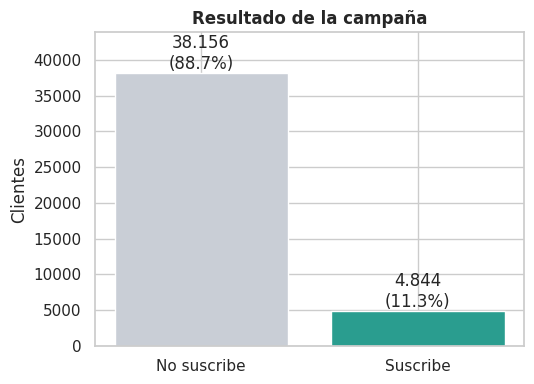

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4))
conteo = df["y"].value_counts().sort_index()
barras = ax.bar(["No suscribe", "Suscribe"], conteo.values, color=[COLOR_NO, COLOR_SI])
for barra, n in zip(barras, conteo.values):
    ax.text(barra.get_x() + barra.get_width() / 2, n, f"{n:,}\n({n / len(df):.1%})".replace(",", "."), ha="center", va="bottom")
ax.set_title("Resultado de la campaña")
ax.set_ylabel("Clientes")
ax.set_ylim(0, conteo.max() * 1.15)

fig.tight_layout()
fig.savefig(RUTA_GRAFICOS / "01_variable_objetivo.png", dpi=130, bbox_inches="tight")
plt.show()

### 5.2 Distribución de las variables numéricas

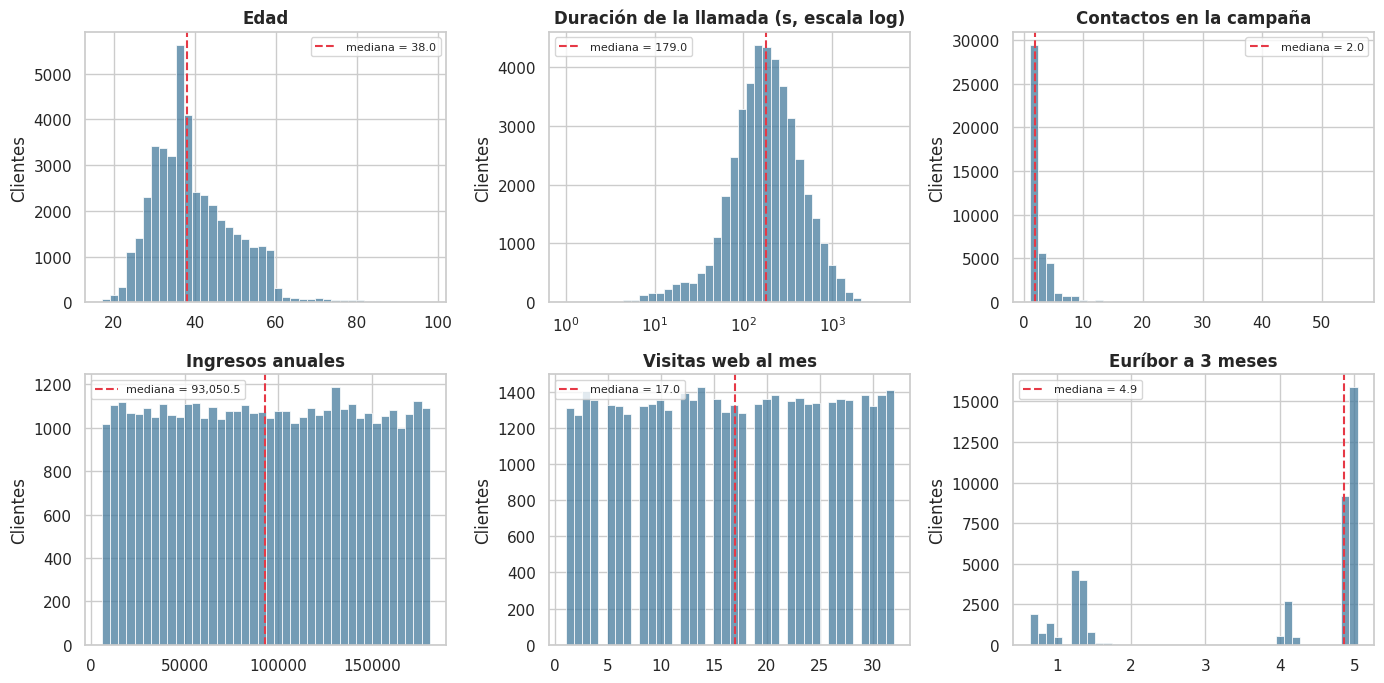

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (col, titulo, log) in zip(axes.ravel(), [
    ("age", "Edad", False), ("duration", "Duración de la llamada (s, escala log)", True),
    ("campaign", "Contactos en la campaña", False), ("Income", "Ingresos anuales", False),
    ("NumWebVisitsMonth", "Visitas web al mes", False), ("euribor3m", "Euríbor a 3 meses", False),
]):
    datos = df[col][df[col] > 0] if log else df[col]
    sns.histplot(datos, bins=40, log_scale=log, color="#457b9d", ax=ax)
    ax.axvline(datos.median(), color="#e63946", ls="--", label=f"mediana = {datos.median():,.1f}")
    ax.set(title=titulo, xlabel="", ylabel="Clientes")
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(RUTA_GRAFICOS / "02_distribuciones.png", dpi=130, bbox_inches="tight")
plt.show()

`Income` y `NumWebVisitsMonth` son prácticamente planos (todos los valores son igual de frecuentes), algo poco habitual en datos reales. `duration` solo se parece a una campana en escala logarítmica, y `campaign` está muy concentrada en 1-3 contactos con una cola larga.

### 5.3 Perfil del cliente y suscripción

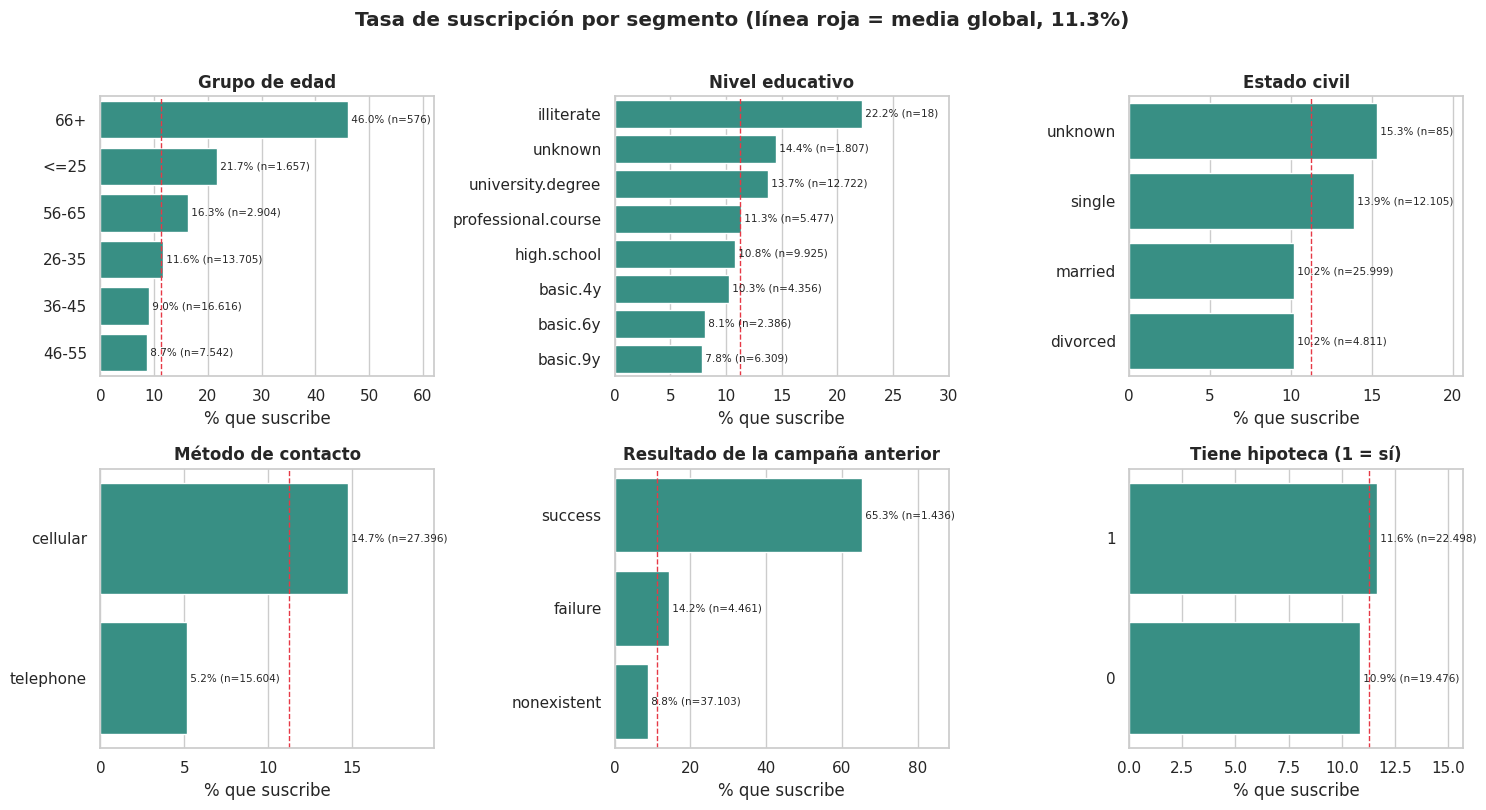

In [ ]:
ORDEN_POUTCOME = ["success", "failure", "nonexistent"]
media = df["y"].mean() * 100

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
paneles = [
    ("grupo_edad", "Grupo de edad", None), ("education", "Nivel educativo", None),
    ("marital", "Estado civil", None), ("contact", "Método de contacto", None),
    ("poutcome", "Resultado de la campaña anterior", ORDEN_POUTCOME), ("housing", "Tiene hipoteca (1 = sí)", None),
]
for ax, (col, titulo, orden) in zip(axes.ravel(), paneles):
    t = tasa_conversion(df, col)
    t = t.loc[orden] if orden else t.sort_values("conversion", ascending=False)
    sns.barplot(x=t["conversion"], y=t.index.astype(str), color=COLOR_SI, ax=ax)
    ax.axvline(media, color="#e63946", ls="--", lw=1)
    for i, (conv, n) in enumerate(zip(t["conversion"], t["clientes"])):
        ax.text(conv, i, f" {conv:.1f}% (n={n:,})".replace(",", "."), va="center", fontsize=7.5)
    ax.set(title=titulo, xlabel="% que suscribe", ylabel="", xlim=(0, t["conversion"].max() * 1.35))
fig.suptitle(f"Tasa de suscripción por segmento (línea roja = media global, {media:.1f}%)", fontweight="bold", y=1.01)

fig.tight_layout()
fig.savefig(RUTA_GRAFICOS / "03_segmentos_clientes.png", dpi=130, bbox_inches="tight")
plt.show()

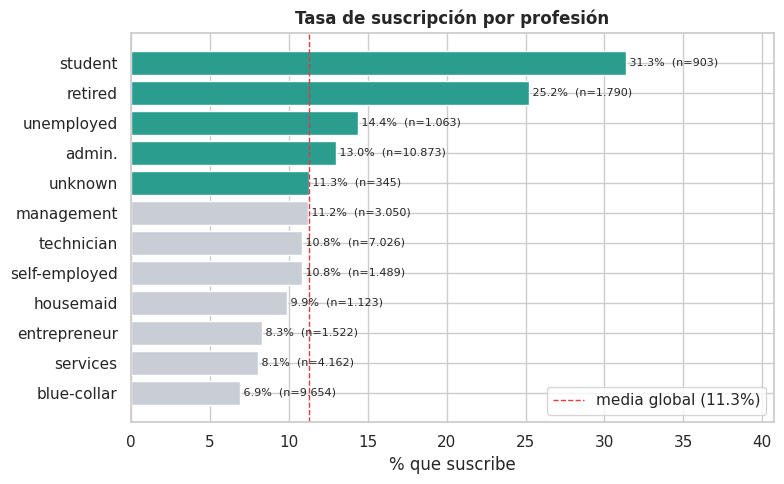

In [ ]:
t = tasa_conversion(df, "job").sort_values("conversion")
fig, ax = plt.subplots(figsize=(8, 5))
colores = [COLOR_SI if v > media else COLOR_NO for v in t["conversion"]]
ax.barh(t.index, t["conversion"], color=colores)
ax.axvline(media, color="#e63946", ls="--", lw=1, label=f"media global ({media:.1f}%)")
for i, (conv, n) in enumerate(zip(t["conversion"], t["clientes"])):
    ax.text(conv, i, f" {conv:.1f}%  (n={n:,})".replace(",", "."), va="center", fontsize=8)
ax.set(title="Tasa de suscripción por profesión", xlabel="% que suscribe")
ax.legend(loc="lower right")
ax.set_xlim(0, t["conversion"].max() * 1.3)

fig.tight_layout()
fig.savefig(RUTA_GRAFICOS / "04_profesion.png", dpi=130, bbox_inches="tight")
plt.show()

### 5.4 La llamada: duración y número de contactos

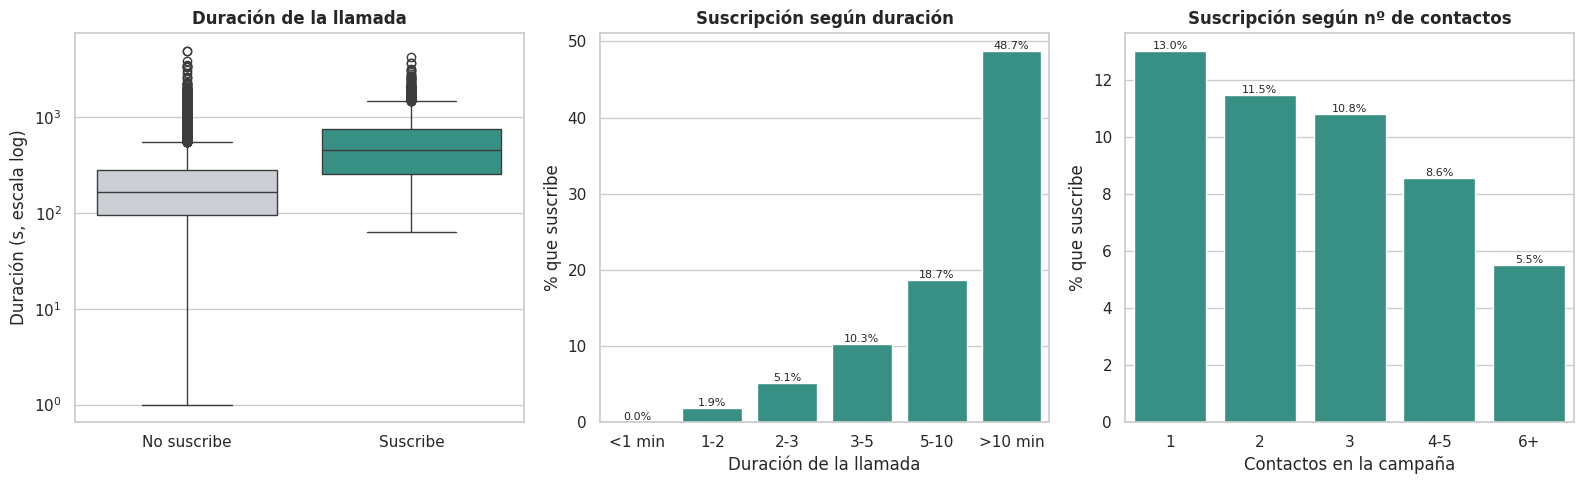

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df[df["duration"] > 0], x="y", y="duration", palette=[COLOR_NO, COLOR_SI], hue="y", legend=False, ax=axes[0])
axes[0].set(yscale="log", xticks=[0, 1], xticklabels=["No suscribe", "Suscribe"], xlabel="", ylabel="Duración (s, escala log)", title="Duración de la llamada")

df["tramo_duracion"] = pd.cut(df["duration"], bins=[-1, 60, 120, 180, 300, 600, 6000], labels=["<1 min", "1-2", "2-3", "3-5", "5-10", ">10 min"])
t = tasa_conversion(df, "tramo_duracion")
sns.barplot(x=t.index.astype(str), y=t["conversion"], color=COLOR_SI, ax=axes[1])
axes[1].set(title="Suscripción según duración", xlabel="Duración de la llamada", ylabel="% que suscribe")

t = tasa_conversion(df, "tramo_contactos")
sns.barplot(x=t.index.astype(str), y=t["conversion"], color=COLOR_SI, ax=axes[2])
axes[2].set(title="Suscripción según nº de contactos", xlabel="Contactos en la campaña", ylabel="% que suscribe")
for ax in axes[1:]:
    for c in ax.containers:
        ax.bar_label(c, fmt="%.1f%%", fontsize=8)

fig.tight_layout()
fig.savefig(RUTA_GRAFICOS / "05_llamada.png", dpi=130, bbox_inches="tight")
plt.show()

**Precaución:** `duration` solo se conoce *después* de la llamada, así que sirve para describir lo ocurrido pero no para decidir a quién llamar. La relación es real pero hay que leerla al revés: quien está interesado habla más tiempo.

### 5.5 Contexto económico

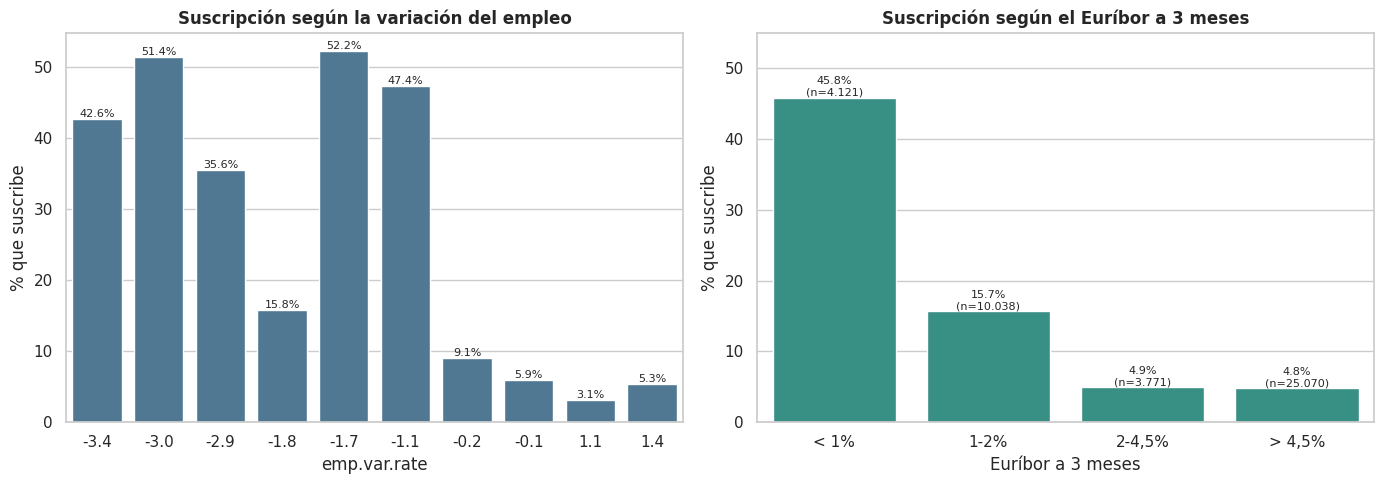

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

t = tasa_conversion(df, "emp.var.rate")
sns.barplot(x=t.index.astype(str), y=t["conversion"], color="#457b9d", ax=axes[0])
axes[0].set(title="Suscripción según la variación del empleo", xlabel="emp.var.rate", ylabel="% que suscribe")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.1f%%", fontsize=8)

# El Euríbor se concentra en tres zonas (~1%, ~4% y ~5%), por eso se agrupa a mano
df["tramo_euribor"] = pd.cut(df["euribor3m"], bins=[0, 1, 2, 4.5, 5.1], labels=["< 1%", "1-2%", "2-4,5%", "> 4,5%"])
t = tasa_conversion(df, "tramo_euribor")
sns.barplot(x=t.index.astype(str), y=t["conversion"], color=COLOR_SI, ax=axes[1])
axes[1].set(title="Suscripción según el Euríbor a 3 meses", xlabel="Euríbor a 3 meses", ylabel="% que suscribe")
for c, n in zip(axes[1].containers, [t["clientes"]]):
    axes[1].bar_label(c, labels=[f"{v:.1f}%\n(n={k:,})".replace(",", ".") for v, k in zip(t["conversion"], n)], fontsize=8)
axes[1].set_ylim(0, t["conversion"].max() * 1.2)

fig.tight_layout()
fig.savefig(RUTA_GRAFICOS / "06_contexto_economico.png", dpi=130, bbox_inches="tight")
plt.show()

### 5.6 Correlaciones

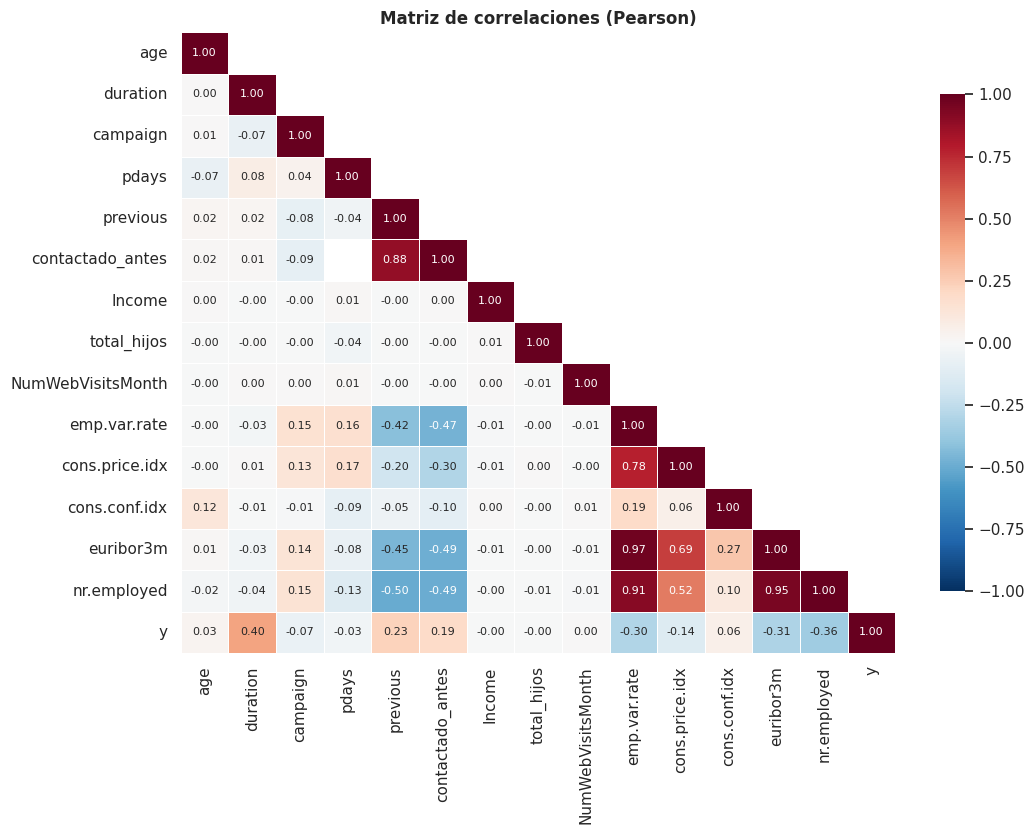

In [ ]:
columnas = ["age", "duration", "campaign", "pdays", "previous", "contactado_antes", "Income", "total_hijos",
            "NumWebVisitsMonth", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed", "y"]
corr = df[columnas].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 8.5))
mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot_kws={"size": 8}, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriz de correlaciones (Pearson)")
ax.grid(False)

fig.tight_layout()
fig.savefig(RUTA_GRAFICOS / "07_correlaciones.png", dpi=130, bbox_inches="tight")
plt.show()

Las variables macroeconómicas (`emp.var.rate`, `euribor3m`, `nr.employed`, `cons.price.idx`) están **muy correlacionadas entre sí**: miden casi lo mismo (el ciclo económico), así que no aportan información independiente. Las más relacionadas con `y` son `nr.employed`, `duration`, `euribor3m` y las de contactos previos.

### 5.7 ¿Influyen los datos del Excel (ingresos, hijos, visitas web) o la fecha?

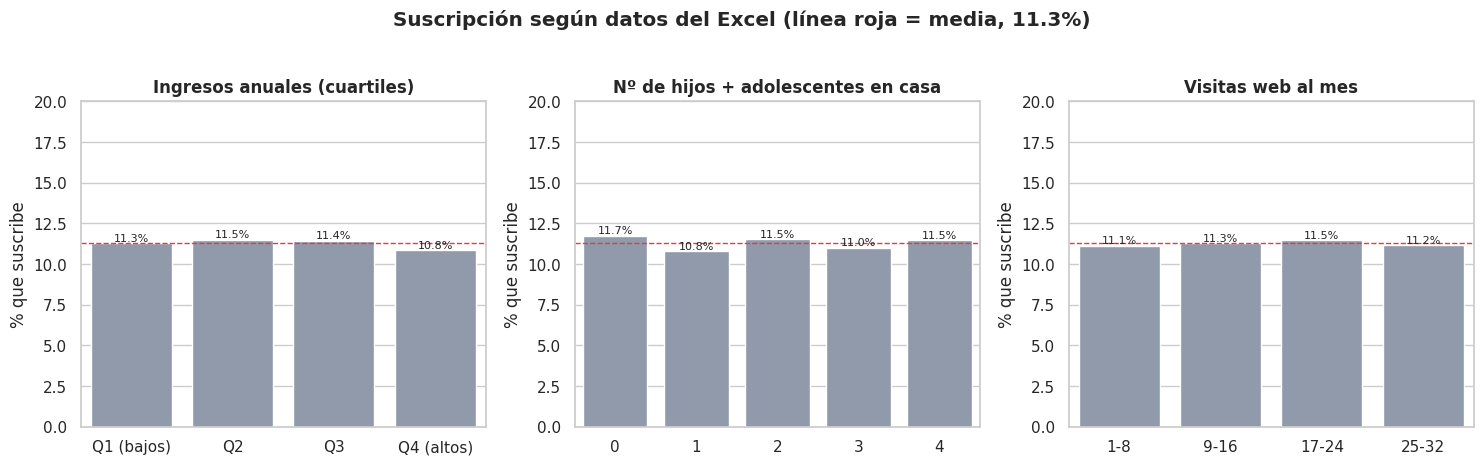

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (col, titulo) in zip(axes, [
    ("tramo_ingresos", "Ingresos anuales (cuartiles)"), ("total_hijos", "Nº de hijos + adolescentes en casa"),
    ("tramo_visitas_web", "Visitas web al mes"),
]):
    t = tasa_conversion(df, col)
    sns.barplot(x=t.index.astype(str), y=t["conversion"], color="#8d99ae", ax=ax)
    ax.axhline(media, color="#e63946", ls="--", lw=1)
    ax.set(title=titulo, xlabel="", ylabel="% que suscribe", ylim=(0, 20))
    for c in ax.containers:
        ax.bar_label(c, fmt="%.1f%%", fontsize=8)
fig.suptitle(f"Suscripción según datos del Excel (línea roja = media, {media:.1f}%)", fontweight="bold", y=1.03)

fig.tight_layout()
fig.savefig(RUTA_GRAFICOS / "08_demografia.png", dpi=130, bbox_inches="tight")
plt.show()

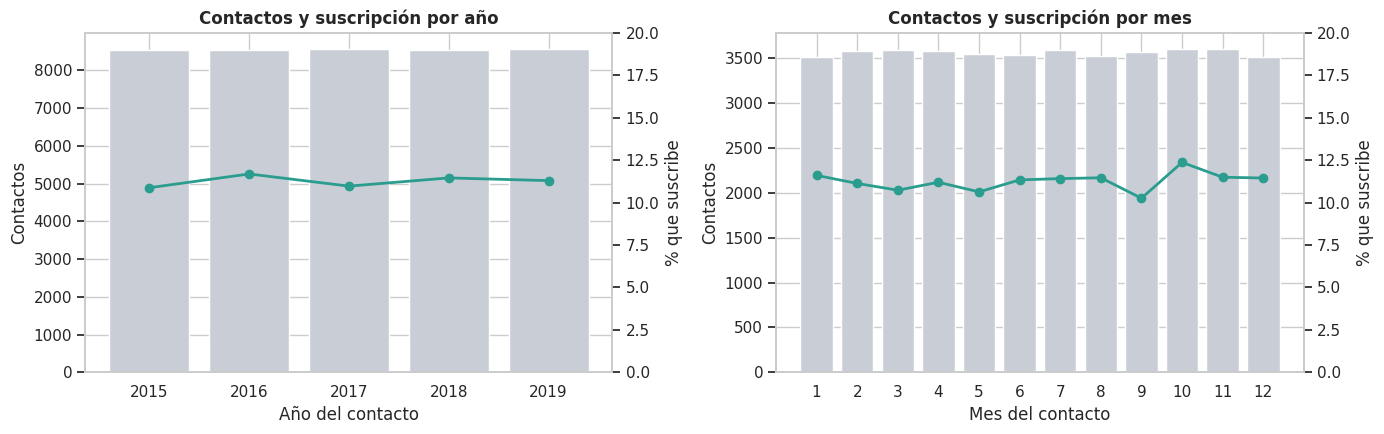

In [ ]:
con_fecha = df.dropna(subset=["date"])
por_anio = con_fecha.groupby("contact_year").agg(contactos=("y", "size"), conversion=("y", "mean"))
por_mes = con_fecha.groupby("contact_month").agg(contactos=("y", "size"), conversion=("y", "mean"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, tabla, etiqueta in [(axes[0], por_anio, "Año del contacto"), (axes[1], por_mes, "Mes del contacto")]:
    ax.bar(tabla.index.astype(str), tabla["contactos"], color=COLOR_NO)
    ax.set(xlabel=etiqueta, ylabel="Contactos")
    ax2 = ax.twinx()
    ax2.plot(tabla.index.astype(str), tabla["conversion"] * 100, color=COLOR_SI, marker="o", lw=2)
    ax2.set(ylabel="% que suscribe", ylim=(0, 20))
    ax2.grid(False)
axes[0].set_title("Contactos y suscripción por año")
axes[1].set_title("Contactos y suscripción por mes")

fig.tight_layout()
fig.savefig(RUTA_GRAFICOS / "09_evolucion_temporal.png", dpi=130, bbox_inches="tight")
plt.show()

### 5.8 Una correlación engañosa: el año de alta del cliente

Al agrupar por el año en que el cliente entró en el banco (la hoja del Excel de la que viene) aparece algo llamativo: la suscripción pasa de un 4,6% a un 23%. Antes de darlo por bueno hay que preguntarse **por qué**.

In [ ]:
por_alta = df.groupby("anio_alta").agg(
    clientes=("y", "size"), conversion=("y", "mean"), euribor_medio=("euribor3m", "mean"), empleo_medio=("emp.var.rate", "mean"),
)
por_alta["conversion"] *= 100
por_alta

,clientes,conversion,euribor_medio,empleo_medio
anio_alta,,,,
2012,20018,4.586,4.917,1.285
2013,8918,7.737,4.076,0.288
2014,14064,23.009,1.473,-1.776


In [ ]:
# Si el año de alta influyera de verdad, seguiría importando DENTRO de un mismo periodo económico.
# Restamos a cada cliente la tasa media de suscripción de su periodo y volvemos a correlacionar.
df["y_relativo_al_periodo"] = df["y"] - df.groupby(GRUPO_MACRO)["y"].transform("mean")

print("Correlación anio_alta - y:                              ", round(df["anio_alta"].corr(df["y"]), 3))
print("Correlación anio_alta - y, descontando el periodo:      ", round(df["anio_alta"].corr(df["y_relativo_al_periodo"]), 3))

Correlación anio_alta - y:                               0.25
Correlación anio_alta - y, descontando el periodo:       0.002


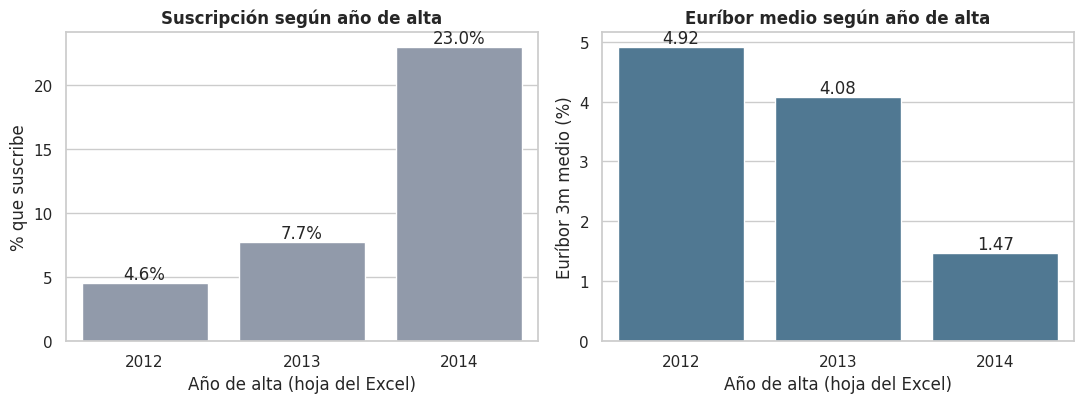

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.barplot(x=por_alta.index.astype(str), y=por_alta["conversion"], color="#8d99ae", ax=axes[0])
axes[0].set(title="Suscripción según año de alta", xlabel="Año de alta (hoja del Excel)", ylabel="% que suscribe")
axes[0].bar_label(axes[0].containers[0], fmt="%.1f%%")
sns.barplot(x=por_alta.index.astype(str), y=por_alta["euribor_medio"], color="#457b9d", ax=axes[1])
axes[1].set(title="Euríbor medio según año de alta", xlabel="Año de alta (hoja del Excel)", ylabel="Euríbor 3m medio (%)")
axes[1].bar_label(axes[1].containers[0], fmt="%.2f")

fig.tight_layout()
fig.savefig(RUTA_GRAFICOS / "10_anio_alta_espurio.png", dpi=130, bbox_inches="tight")
plt.show()

**Es un efecto aparente, no real.** Las hojas del Excel están ordenadas igual que el CSV, y el CSV está ordenado por periodo económico: los clientes de la hoja 2012 son los del principio del fichero (Euríbor ≈ 4,9%) y los de 2014 los del final (Euríbor ≈ 1,5%). El año de alta solo "hereda" el efecto del contexto económico: al descontarlo, la correlación pasa de 0,25 a prácticamente 0. Lo mismo ocurre con `antiguedad_anios`, así que **no se interpretan como factores de suscripción**.

## 6. Conclusiones

**Perfil general.** 43.000 contactos, de los cuales suscriben el depósito 4.844 (**11,3%**). Con una base tan baja, lo relevante es qué segmentos se alejan de ese 11%.

**Qué sí marca la diferencia**

1. **Resultado de la campaña anterior.** Es el factor más fuerte: quienes ya suscribieron en una campaña previa vuelven a hacerlo el **65,3%** de las veces, frente al 8,8% de quienes no habían sido contactados. Haber sido contactado antes (aunque fuese un fracaso) ya sube la tasa al 26,7%.
2. **Contexto económico.** Con el Euríbor por debajo del 1% suscribe el **45,8%**; entre 1% y 2%, el 15,7%; por encima del 2%, solo el 4,8%. `nr.employed`, `euribor3m` y `emp.var.rate` son las variables macro más ligadas a `y` (correlaciones de -0,36, -0,31 y -0,30), pero están casi calcadas entre sí (0,91 a 0,97), así que representan un único factor: el ciclo económico. Como solo hay unos 26 periodos económicos distintos, es una comparación entre periodos y no prueba causalidad.
3. **Duración de la llamada.** Los que suscriben hablan mucho más (mediana de 449 s frente a 163 s); ninguna llamada de menos de un minuto acabó en suscripción y por encima de 10 minutos lo hace el 48,7%. Es una consecuencia de la venta, no una causa (solo se conoce después de llamar).
4. **Insistir no compensa.** La tasa baja del 13,0% con un contacto al 5,5% con seis o más.
5. **Método de contacto.** El móvil (`cellular`) convierte el **14,7%** y el teléfono fijo el **5,2%**. La diferencia se mantiene entre clientes sin contacto previo (11,7% frente a 4,6%).
6. **Profesión y edad.** Estudiantes (31,3%) y jubilados (25,2%) destacan: son el 6,3% de los clientes y aportan el 15,2% de las suscripciones. Por el lado contrario, los `blue-collar` (6,9%) y `services` (8,1%). Por edad, hay forma de "U": ≤25 años (21,7%) y mayores de 55 (16,3% de 56 a 65 y 46,0% de más de 65, con solo 576 clientes) frente al 9% de 36 a 55 años. También suscriben más los solteros (13,9%) que los casados (10,2%).

**Qué no influye (y por qué no hay que buscarlo)**

- **Ingresos, hijos y visitas web** del Excel: todas las categorías rondan el 11%, con correlaciones de prácticamente 0.
- **Fecha del contacto** (año o mes): sin tendencia ni estacionalidad. Con unos 3.500 contactos por mes, oscilaciones de ±1 punto entran dentro del ruido aleatorio.
- **Hipoteca y préstamo personal**: diferencias de menos de un punto.
- **Año de alta y antigüedad:** parecen influir, pero es un efecto aparente del orden de los datos (apartado 5.8).

**Limitaciones y cautelas**

- Variable objetivo desbalanceada (11,3% de positivos): cualquier análisis futuro debe tenerlo en cuenta.
- Varias columnas (`Income`, `NumWebVisitsMonth`, `Kidhome`, `Teenhome`, la fecha) tienen distribuciones uniformes, algo poco realista, y las coordenadas son de EE. UU. aunque el banco es portugués. Todo apunta a que parte de los datos son sintéticos, por lo que la ausencia de relación en ellas no debe extrapolarse a un caso real.
- Las categorías con pocos clientes (`illiterate`, n = 18; `unknown`) dan porcentajes poco fiables.
- Imputaciones: `age` (12% de nulos) con la mediana de su profesión, y `euribor3m` (21,5%) con la mediana de su periodo económico. `cons.price.idx` se recuperó de forma exacta porque cada periodo solo tiene un valor posible.

**Recomendación de negocio.** Priorizar la llamada a clientes con contacto previo exitoso, usar el móvil frente al fijo, no insistir más de 2-3 veces al mismo cliente y concentrar el esfuerzo en los momentos de tipos de interés bajos. Estudiantes y jubilados son los segmentos con mejor respuesta.